# Results Analysis

Precision, Recall, and Accuracy across spurious conditions, grouped by model.

In [36]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open("../results/summary.json") as f:
    results = json.load(f)

CONDITIONS = [
    "pos0.0_neg0.5", "pos0.3_neg0.5",
    "pos0.5_neg0.0", "pos0.5_neg0.3"
]
DIFFICULTIES = ["obvious", "intermediate"]
SHAPES = ["circle", "wave"]
METRICS = ["precision", "recall"]
METRIC_COLORS = {"precision": "#4C72B0", "recall": "#DD8452", "accuracy": "#55A868"}
COND_LABELS = [c.replace("pos", "p=").replace("_neg", "\nn=") for c in CONDITIONS]


def plot_model(model):
    fig, axes = plt.subplots(
        len(DIFFICULTIES), len(SHAPES),
        figsize=(14, 8), sharey=True, sharex=False
    )
    bw = 0.8 / len(METRICS)
    x = np.arange(len(CONDITIONS))
    legend_handles = [
        mpatches.Patch(facecolor=METRIC_COLORS[m], label=m.capitalize())
        for m in METRICS
    ]
    for r, difficulty in enumerate(DIFFICULTIES):
        for c, shape in enumerate(SHAPES):
            ax = axes[r][c]
            for m_i, metric in enumerate(METRICS):
                offsets = x + (m_i - len(METRICS) / 2 + 0.5) * bw
                vals = [
                    results.get(f"{model}_{shape}_{difficulty}_{cond}", {}).get(metric, 0)
                    for cond in CONDITIONS
                ]
                ax.bar(offsets, vals, width=bw, color=METRIC_COLORS[metric],
                       alpha=0.85, edgecolor="white", linewidth=0.3)

            # Divider between "pos0.3_neg0.5" (idx 1) and "pos0.5_neg0.0" (idx 2)
            ax.axvline(1.5, color="black", linestyle="--", linewidth=0.8, alpha=0.6)

            ax.set_xticks(x)
            ax.set_xticklabels(COND_LABELS, fontsize=7)
            ax.set_ylim(0, 1.1)
            ax.yaxis.grid(True, linestyle="--", alpha=0.5)
            ax.set_axisbelow(True)
            if r == 0:
                ax.set_title(shape.capitalize(), fontsize=11, fontweight="bold")
            if c == 0:
                ax.set_ylabel(f"{difficulty.capitalize()}\nScore", fontsize=9)

    fig.legend(handles=legend_handles, loc="upper center", ncol=len(METRICS),
               fontsize=9, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(
        f"{model.upper()} — Precision, Recall & Accuracy by Spurious Condition",
        fontsize=13, fontweight="bold", y=1.06
    )
    plt.tight_layout()
    plt.savefig(f"../results/{model}_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"Loaded {len(results)} entries from summary.json")

Loaded 48 entries from summary.json


## AlexNet

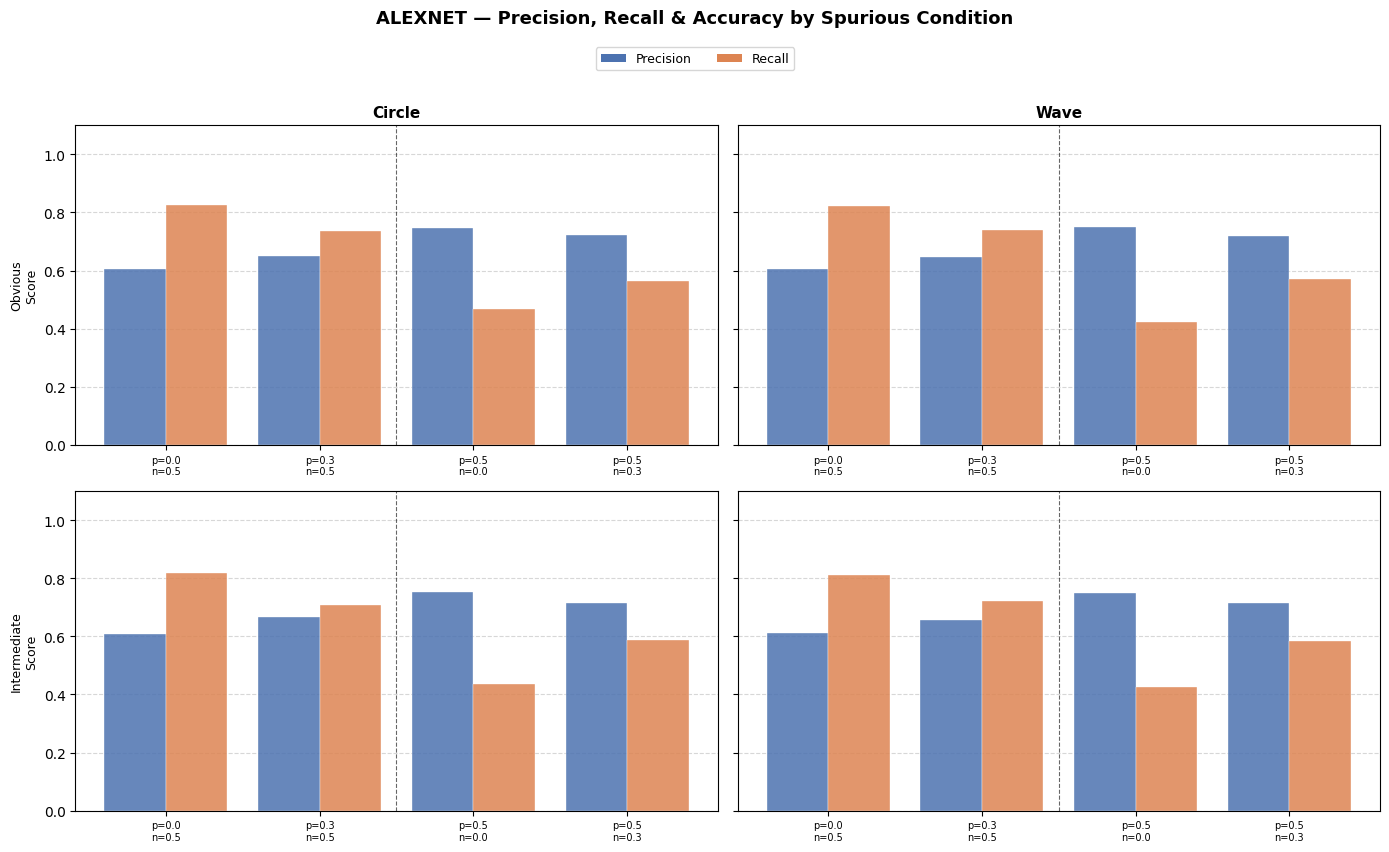

In [37]:
plot_model("alexnet")

## InceptionV3

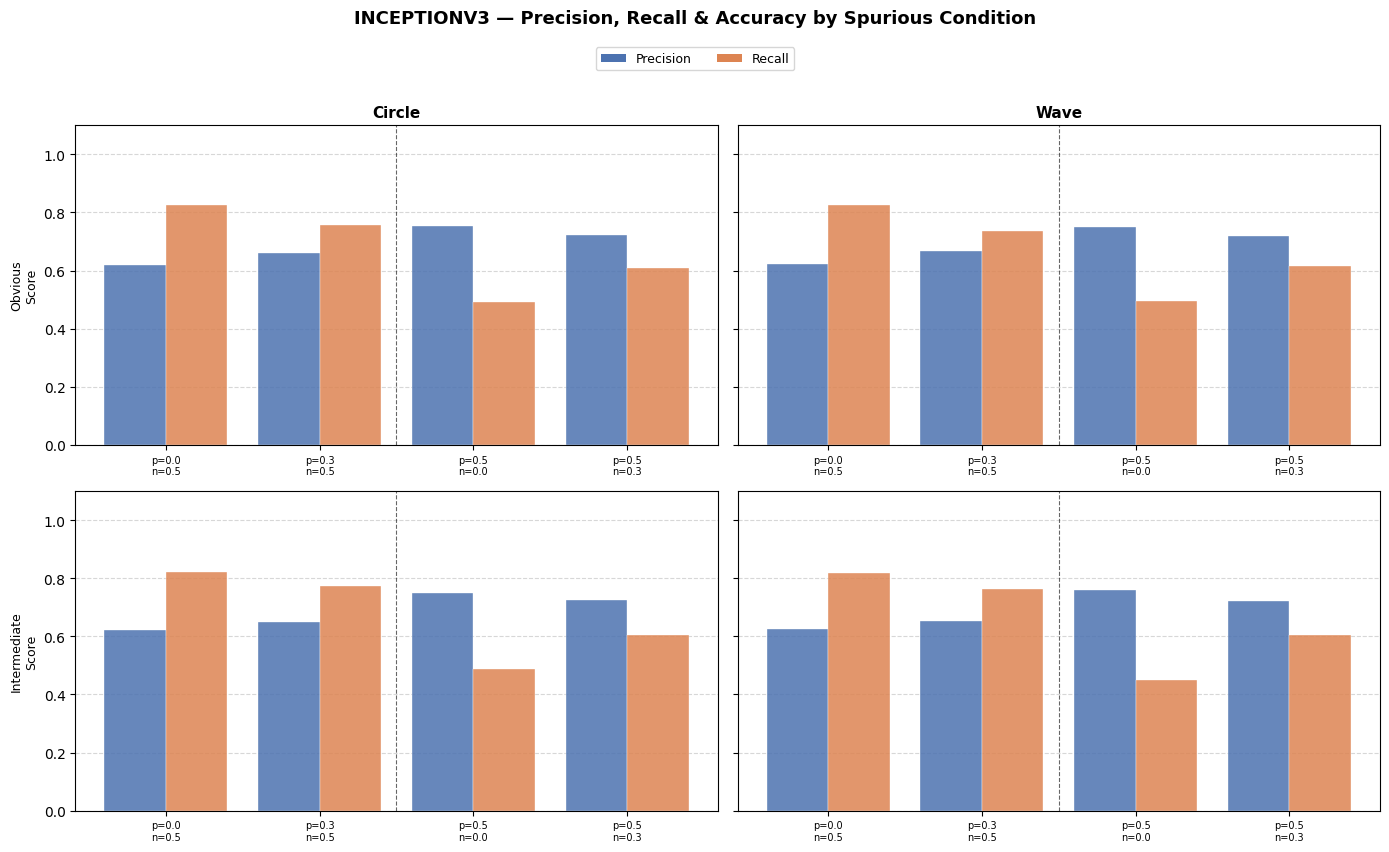

In [38]:
plot_model("inceptionv3")

## ResNet50

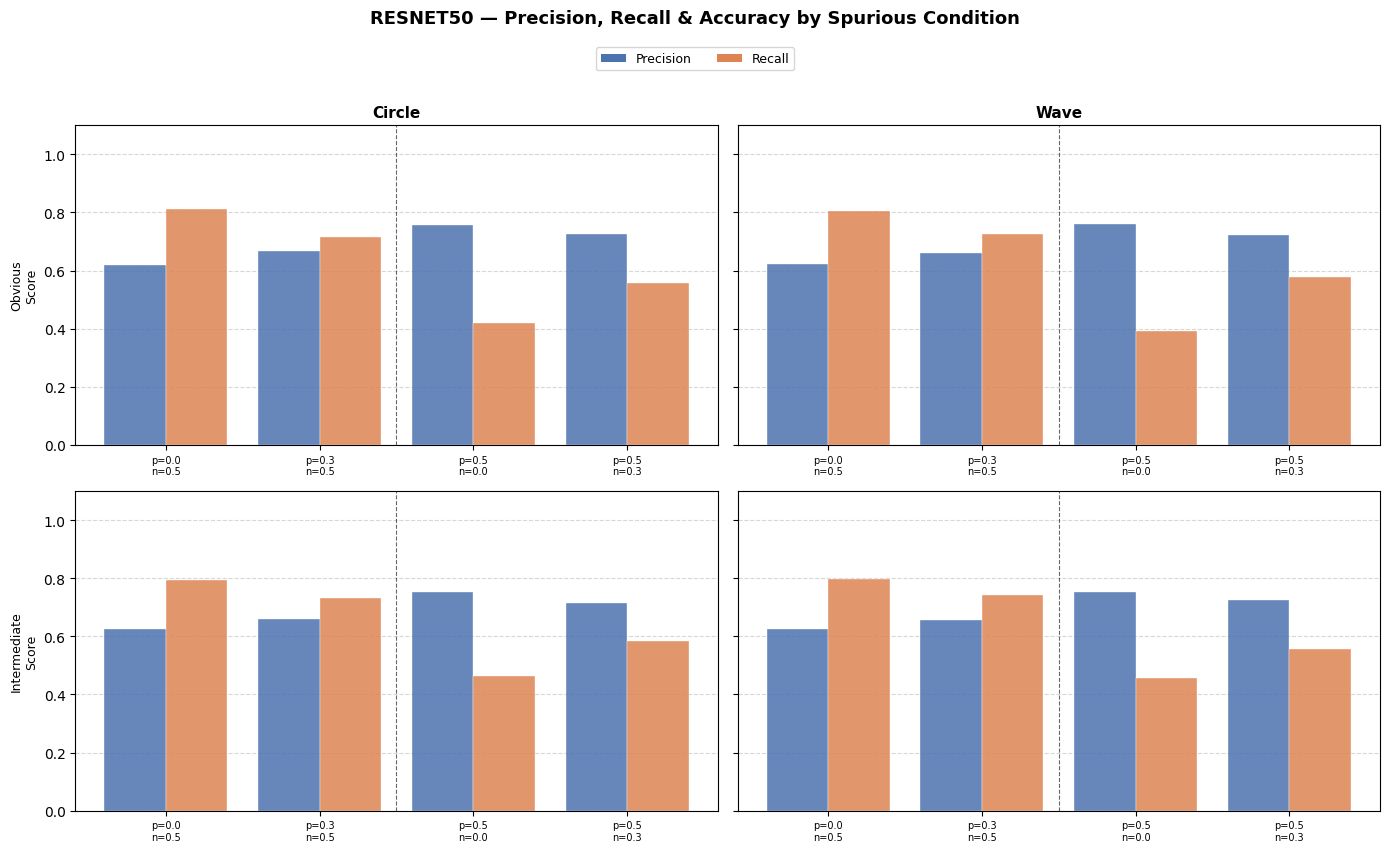

In [39]:
plot_model("resnet50")